# Budgeted MLMC vs MLQMC for the Analytic Function 

## Imports

In [1]:
import mlqmcpy as mp
from mlqmcpy.problems.analytic import analytic

In [2]:
import numpy as np
import scipy.stats
import qmcpy as qp
import os

In [3]:
import torch 
torch.set_default_dtype(torch.float64)

In [4]:
import matplotlib 
from matplotlib import pyplot
pyplot.style.use("seaborn-v0_8-whitegrid")
COLORS = ['xkcd:purple', 'xkcd:green', 'xkcd:blue', 'xkcd:red', 'xkcd:turquoise', 'xkcd:pink', 'xkcd:brown', 'xkcd:light blue', 'xkcd:teal', 'xkcd:orange']
pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
WIDTH = 2*(500/72)
LW = 3
alpha = .2

## Parameters

In [5]:
force_experiment = False
datafile = "budgeted_comparison_analytic.data.big.npy"

## Experiment

In [6]:
if not os.path.isfile(datafile) or force_experiment:
    # parameters 
    dimension = 2
    num_levels = 3
    initial_sample_size = 2**(num_levels-np.arange(num_levels)+6)
    max_budgets = 1000*np.arange(1,16)
    trials = 3
    zip_IteratorClass_DiscreteDistribClass = [
        (mp.GreedyMLQMCIterator,qp.Lattice),
        (mp.GreedyMLQMCIterator,qp.DigitalNetB2),
        (mp.GreedyFastGaussianProcessMLQMCIterator,qp.Lattice),
        (mp.GreedyFastGaussianProcessMLQMCIterator,qp.DigitalNetB2),
        (mp.FastMultiTaskGaussianProcessMLQMCIterator,qp.Lattice),
        (mp.FastMultiTaskGaussianProcessMLQMCIterator,qp.DigitalNetB2),
    ]
    # experiment
    names = ["%s %s"%(IteratorClass.__name__,DiscreteDistribClass.__name__) for (IteratorClass,DiscreteDistribClass) in zip_IteratorClass_DiscreteDistribClass]
    true_solution = analytic.exact.Q.mean(level=num_levels-1)
    cost_per_level = 2.**(np.arange(num_levels)-num_levels+1) # Rescale so that finest level has unit cost
    print("max_budgets: %s"%max_budgets)
    print("cost_per_level: %s"%str(cost_per_level))
    print("initial_sample_size: %s"%str(initial_sample_size))
    print("initial cost: %.1f"%(cost_per_level*initial_sample_size).sum())
    print()
    costs = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    means = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    std_errors = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    true_errors = np.empty((len(zip_IteratorClass_DiscreteDistribClass),len(max_budgets),trials))
    for i,(IteratorClass,DiscreteDistribClass) in enumerate(zip_IteratorClass_DiscreteDistribClass):
        print("%s"%names[i])
        for j in range(len(max_budgets)):
            max_budget = max_budgets[j]
            print("\tbudget = %d"%max_budget)
            for t in range(trials):
                iterator = IteratorClass(
                    dimension,
                    initial_sample_size=initial_sample_size,
                    cost_per_level=cost_per_level,
                    max_budget = max_budget,
                    discrete_distribution_type = DiscreteDistribClass)
                problem = analytic if isinstance(iterator,mp.FastMultiTaskGaussianProcessMLQMCIterator) else analytic.ml
                problem_tf = (lambda level,x: problem(level,1-2*np.abs(x-1/2))) if DiscreteDistribClass==qp.Lattice else problem
                for iter, new_samples in enumerate(iterator):
                    new_results = {level: problem_tf(level,samples) for level,samples in new_samples.items()}
                    iterator.update(new_results)
                costs[i,j,t] = iterator.cost
                means[i,j,t] = iterator.mean
                std_errors[i,j,t] = iterator.standard_error
                true_errors[i,j,t] = np.abs(true_solution-means[i,j,t])
                print("\t\ttrial: %-6d iteration: %-6d cost: %-10d mean: %-15.3e std error: %-15.3e true error: %-15.3e"%\
                    (t,iter,costs[i,j,t],means[i,j,t],std_errors[i,j,t],true_errors[i,j,t]))
        print()
    data = {
        "dimension": dimension,
        "num_levels": num_levels,
        "initial_sample_size": initial_sample_size,
        "max_budgets": max_budgets,
        "names": names,
        "costs": costs,
        "means": means,
        "std_errors": std_errors,
        "true_errors": true_errors,
    }
    np.save(datafile,data)
else:
    data = np.load(datafile,allow_pickle=True)[()]
    dimension = data["dimension"]
    num_levels = data["num_levels"]
    initial_sample_size = data["initial_sample_size"]
    max_budgets = data["max_budgets"]
    names = data["names"]
    costs = data["costs"]
    means = data["means"]
    std_errors = data["std_errors"]
    true_errors = data["true_errors"]
    trials = costs.shape[-1]

max_budgets: [ 1000  2000  3000  4000  5000  6000  7000  8000  9000 10000 11000 12000
 13000 14000 15000]
cost_per_level: [0.25 0.5  1.  ]
initial_sample_size: [512 256 128]
initial cost: 384.0

GreedyMLQMCIterator Lattice
	budget = 1000
		trial: 0      iteration: 0      cost: 3072       mean: 5.746e-01       std error: 3.944e-07       true error: 2.810e-07      
		trial: 1      iteration: 0      cost: 3072       mean: 5.746e-01       std error: 4.849e-07       true error: 3.564e-08      
		trial: 2      iteration: 0      cost: 3072       mean: 5.746e-01       std error: 4.332e-07       true error: 2.883e-07      
	budget = 2000
		trial: 0      iteration: 0      cost: 3072       mean: 5.746e-01       std error: 5.012e-07       true error: 7.183e-07      
		trial: 1      iteration: 0      cost: 3072       mean: 5.746e-01       std error: 3.328e-07       true error: 4.671e-07      
		trial: 2      iteration: 0      cost: 3072       mean: 5.746e-01       std error: 3.250e-07       true er

/var/folders/xk/w1s5c54x0zv90dgqk3vpmbsw004hmz/T/ipykernel_91862/3787975277.py:42
/var/folders/xk/w1s5c54x0zv90dgqk3vpmbsw004hmz/T/ipykernel_91862/3787975277.py:42


		trial: 0      iteration: 4      cost: 1024       mean: 5.746e-01       std error: 6.258e-06       true error: 1.077e-07      
		trial: 1      iteration: 4      cost: 1024       mean: 5.746e-01       std error: 8.575e-06       true error: 3.446e-07      
		trial: 2      iteration: 4      cost: 1024       mean: 5.746e-01       std error: 9.386e-06       true error: 1.289e-07      
	budget = 2000
		trial: 0      iteration: 7      cost: 2304       mean: 5.746e-01       std error: 3.828e-06       true error: 3.771e-08      
		trial: 1      iteration: 7      cost: 2304       mean: 5.746e-01       std error: 3.828e-06       true error: 1.280e-09      
		trial: 2      iteration: 7      cost: 2048       mean: 5.746e-01       std error: 5.415e-06       true error: 1.026e-07      
	budget = 3000
		trial: 0      iteration: 9      cost: 3072       mean: 5.746e-01       std error: 3.828e-06       true error: 8.654e-09      
		trial: 1      iteration: 9      cost: 3072       mean: 5.746e-01       s

## Analysis

above 0 means it is over budget, below 0 means it is within the budget
as only the FastMultiTaskGaussianProcessMLQMCIterator stays within budget, the rest of the notebook should be taken with a grain of salt


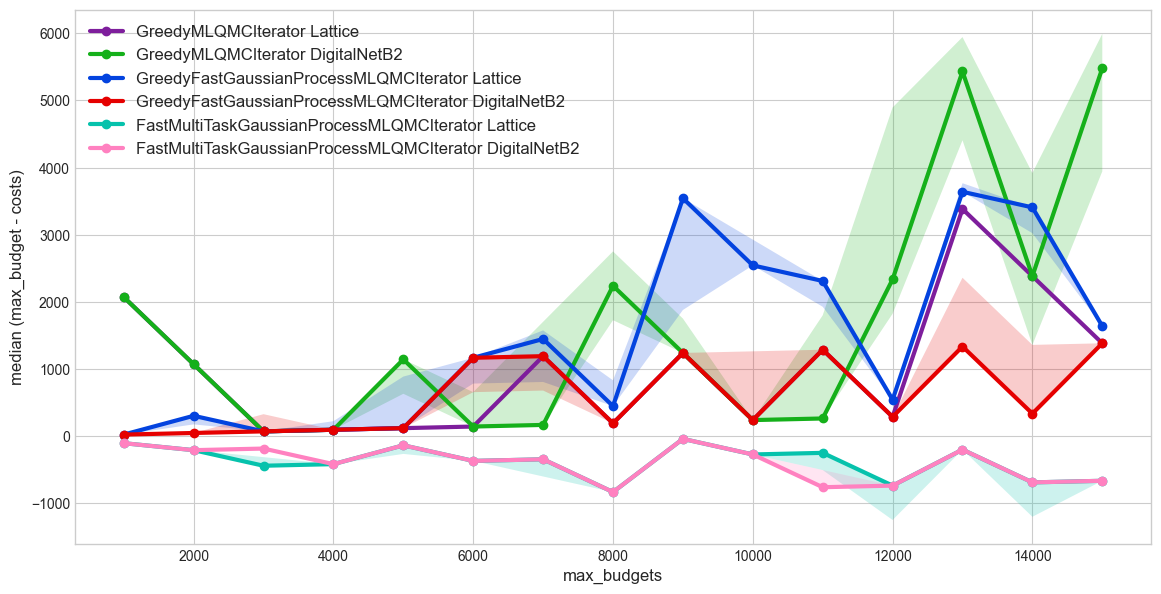

In [7]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(WIDTH,WIDTH/2))
for i,name in enumerate(names):
    vals = costs[i]-max_budgets[:,None]
    q_low = np.nanquantile(vals,.25,axis=1)
    q_med = np.nanquantile(vals,.5,axis=1)
    q_high = np.nanquantile(vals,.75,axis=1)
    ax.plot(max_budgets,q_med,'-o',label=name,linewidth=LW)
    ax.fill_between(max_budgets,q_low,q_high,alpha=alpha)
ax.legend(frameon=False,fontsize="large")
ax.set_xlabel("max_budgets",fontsize="large")
ax.set_ylabel("median (max_budget - costs)",fontsize="large");
print("above 0 means it is over budget, below 0 means it is within the budget")
print("as only the FastMultiTaskGaussianProcessMLQMCIterator stays within budget, the rest of the notebook should be taken with a grain of salt")

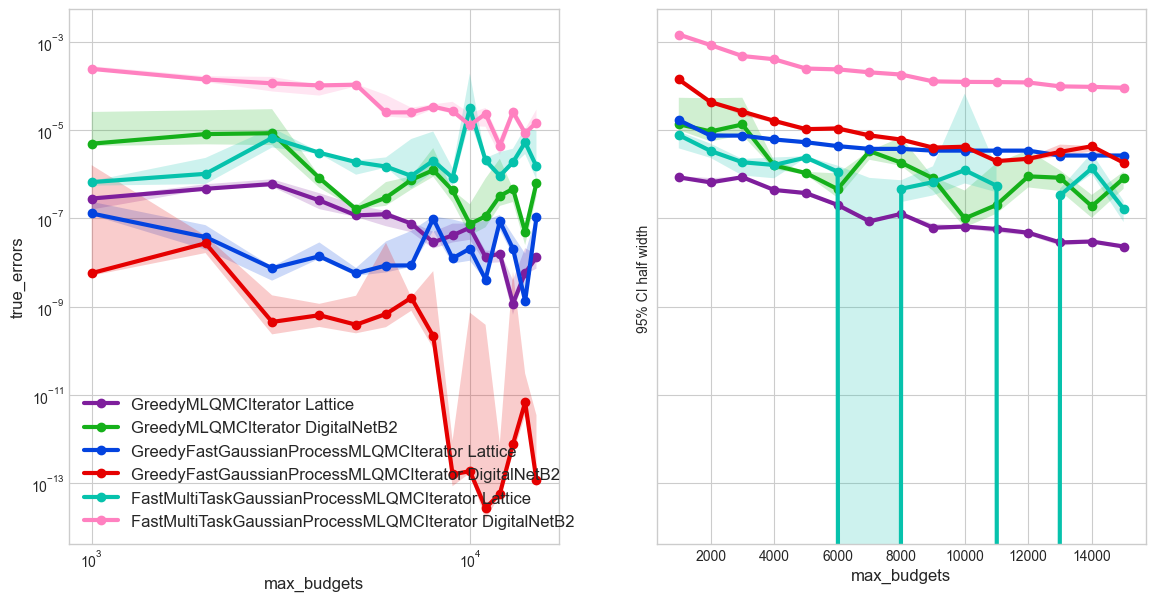

In [8]:
confidence = .95
beta = scipy.stats.norm.ppf(1-(1-confidence)/2)
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(WIDTH,WIDTH/2),sharey=True)
for i,name in enumerate(names):
    for j,vals in enumerate([true_errors[i],beta*std_errors[i]]):
        q_low = np.nanquantile(vals,.25,axis=1)
        q_med = np.nanquantile(vals,.5,axis=1)
        q_high = np.nanquantile(vals,.75,axis=1)
        ax[j].plot(max_budgets,q_med,'-o',label=name,linewidth=LW)
        ax[j].fill_between(max_budgets,q_low,q_high,alpha=alpha)

ax[0].legend(frameon=False,fontsize="large")
ax[0].set_yscale("log",base=10)
ax[0].set_xscale("log",base=10)
ax[0].set_ylabel("true_errors",fontsize="large")
ax[1].set_ylabel("%d%% CI half width "%int(100*confidence))
for j in range(2):
    ax[j].set_xlabel("max_budgets",fontsize="large")


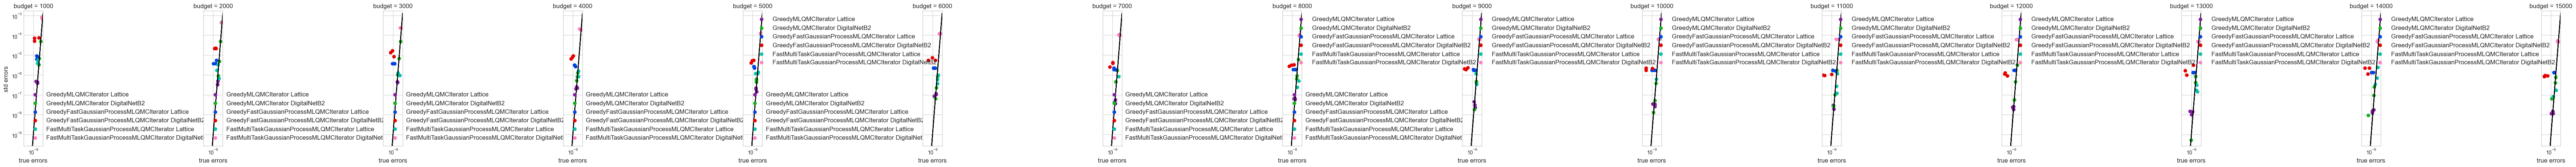

In [9]:
fig,ax = pyplot.subplots(nrows=1,ncols=len(max_budgets),figsize=(WIDTH*len(max_budgets)/3,WIDTH/3),sharex=True,sharey=True)
for i,name in enumerate(names):
    for j in range(len(max_budgets)):
        ax[j].scatter(true_errors[i,j],std_errors[i,j],label=name)
        ax[j].axline(xy1=(0,0),slope=1,color="k")
ax[0].set_xscale("log",base=10)
ax[0].set_yscale("log",base=10)
ax[0].set_ylabel("std errors",fontsize="large")
for j in range(len(max_budgets)):
    ax[j].legend(frameon=False,fontsize="large")#,ncols=len(max_budgets),bbox_to_anchor=(10,-.25))
    ax[j].set_xlabel("true errors",fontsize="large")
    ax[j].set_title("budget = %d"%max_budgets[j])
fig.tight_layout()